## scatter plot with 1000 samples

In [65]:
import pandas as pd
import plotly.express as px
from itertools import combinations
import plotly.io as pio
pio.renderers.default = 'notebook'  # or 'iframe_connected', or 'vscode' if using VS Code
# Load CSV
df = pd.read_csv("patch_statistics.csv")

# Features to visualize

features = ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']

# Generate all pairwise scatter plots
for x, y in combinations(features, 2):
    fig = px.scatter(
        df, x=x, y=y,
        hover_name="patch_name",
        title=f"{x} vs {y}",
        opacity=0.6,
        height=500,
        width=600
    )
    fig.show()


In [66]:
df

,patch_name,avg_R,avg_G,avg_B,std_R,std_G,std_B,label
0,TCGA-3L-AA1B_nonMSIH_0.png,208.191933,207.283577,206.162567,41.835703,41.611461,41.488538,1
1,TCGA-3L-AA1B_nonMSIH_1.png,215.367195,214.834129,214.200729,42.159360,41.790792,41.362622,1
2,TCGA-3L-AA1B_nonMSIH_116.png,215.366226,215.040821,214.401543,40.089819,39.708534,39.317727,1
3,TCGA-3L-AA1B_nonMSIH_129.png,241.702354,240.753803,241.198475,3.331656,6.598430,5.036431,1
4,TCGA-3L-AA1B_nonMSIH_19.png,215.606636,215.090355,214.555332,40.369144,40.051790,39.676427,1
...,...,...,...,...,...,...,...,...
6413,TCGA-WS-AB45_MSIH_x47040_y12800_patch04047.png,228.534599,218.221130,227.322289,15.284639,26.191706,15.837304,0
6414,TCGA-WS-AB45_MSIH_x50624_y28160_patch04308.png,221.863796,206.129025,220.494793,18.409766,29.845987,18.794077,0
6415,TCGA-WS-AB45_MSIH_x51136_y18944_patch04330.png,228.715084,204.965858,220.033642,14.748895,31.790494,19.172442,0
6416,TCGA-WS-AB45_MSIH_x53696_y24576_patch04511.png,210.453911,163.378277,193.408684,27.647703,39.760689,27.099227,0


## SVM model

## model training and evaluation

In [91]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import pandas as pd
import numpy as np


def svm(X_train, y_train, X_test, y_test, kernel='linear', plot_decision=False, patch_names=None):
    model = SVC(kernel=kernel, random_state=42, C=10,gamma=0.1)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    if plot_decision and X_test.shape[1] == 2:
        _plot_decision_boundary(X_test, y_test, model, kernel, patch_names=patch_names)

    if plot_decision and X_test.shape[1] == 3:
        _plot_decision_boundary_3d(X_test, y_test, model, patch_names=patch_names)


    return model

import plotly.graph_objects as go
import pandas as pd
import numpy as np

def _plot_decision_boundary_3d(X, y, model, patch_names=None):
    from sklearn.decomposition import PCA
    import plotly.graph_objects as go

    # Reduce to 3D if necessary
    if X.shape[1] > 3:
        X = PCA(n_components=3).fit_transform(X)

    x, y_, z = X[:, 0], X[:, 1], X[:, 2]
    labels = y

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=x, y=y_, z=z,
        mode='markers',
        marker=dict(size=4, color=labels, colorscale='Viridis', opacity=0.8),
        text=patch_names if patch_names is not None else [''] * len(x),
        hovertemplate="<b>Patch:</b> %{text}<br>x: %{x}<br>y: %{y}<br>z: %{z}<extra></extra>",
    ))

    fig.update_layout(
        title="3D Feature Space",
        scene=dict(xaxis_title='Feature 1', yaxis_title='Feature 2', zaxis_title='Feature 3'),
        height=700
    )

    fig.show()

def _plot_decision_boundary(X, y, model, kernel, patch_names=None):
    """
    Interactive SVM decision boundary plot with hover info for patch names.
    """
    # Decision boundary grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    # Create scatter plot trace for points
    df_plot = pd.DataFrame({
        'x': X[:, 0],
        'y': X[:, 1],
        'label': y,
        'patch_name': patch_names if patch_names is not None else [''] * len(y)
    })

    fig = go.Figure()

    # Add points with hover for patch_name
    for label in np.unique(y):
        subset = df_plot[df_plot['label'] == label]
        fig.add_trace(go.Scatter(
            x=subset['x'],
            y=subset['y'],
            mode='markers',
            name=f"Label {label}",
            marker=dict(size=8),
            hovertemplate="<b>Patch:</b> %{text}<br>R: %{x}<br>G: %{y}<extra></extra>",
            text=subset['patch_name']
        ))

    # Add decision boundary
    fig.add_trace(go.Contour(
        x=np.linspace(x_min, x_max, 500),
        y=np.linspace(y_min, y_max, 500),
        z=Z,
        showscale=False,
        contours=dict(start=0, end=0, size=1, coloring='none', showlines=True),
        line=dict(color='black', width=2),
        hoverinfo='skip',  # disables hover on the contour
        name='Decision Boundary'
    ))

    fig.update_layout(
        title=f"SVM Decision Boundary (kernel='{kernel}')",
        xaxis_title="avg_R",
        yaxis_title="avg_G",
        height=600
    )

    fig.show()

## Testing all combination of three features (non-linear)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations

# Define available feature columns
feature_cols = ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']

# Shuffle and reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split data
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
y_train = df_train['label'].values
y_test = df_test['label'].values
patch_names_test = df_test['patch_name'].values

# Iterate over all 3-feature combinations
for combo in combinations(feature_cols, 3):
    print(f"\n=== Using Features: {combo} ===")

    # Extract and scale features
    X_train = df_train[list(combo)].values
    X_test = df_test[list(combo)].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM and evaluate
    svm_model = svm(X_train_scaled, y_train, X_test_scaled, y_test, kernel='rbf', plot_decision=True)


=== Using Features: ('avg_R', 'avg_G', 'avg_B') ===
Accuracy: 0.9761163032191069

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1587
           1       0.92      0.94      0.93       339

    accuracy                           0.98      1926
   macro avg       0.96      0.96      0.96      1926
weighted avg       0.98      0.98      0.98      1926


Confusion Matrix:
 [[1560   27]
 [  19  320]]

=== Using Features: ('avg_R', 'avg_G', 'std_R') ===
Accuracy: 0.9787123572170301

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1587
           1       0.97      0.91      0.94       339

    accuracy                           0.98      1926
   macro avg       0.97      0.95      0.96      1926
weighted avg       0.98      0.98      0.98      1926


Confusion Matrix:
 [[1576   11]
 [  30  309]]

=== Using Features: ('avg_R', 'avg_G'

## three column Linear model

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations

# Define available feature columns
feature_cols = ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']

# Shuffle and reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split data
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
y_train = df_train['label'].values
y_test = df_test['label'].values
patch_names_test = df_test['patch_name'].values

# Iterate over all 3-feature combinations
for combo in combinations(feature_cols, 3):
    print(f"\n=== Using Features: {combo} ===")

    # Extract and scale features
    X_train = df_train[list(combo)].values
    X_test = df_test[list(combo)].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM and evaluate
    svm_model = svm(X_train_scaled, y_train, X_test_scaled, y_test, kernel='linear', plot_decision=True)



=== Using Features: ('avg_R', 'avg_G', 'avg_B') ===
Accuracy: 0.9719626168224299

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1587
           1       0.89      0.96      0.92       339

    accuracy                           0.97      1926
   macro avg       0.94      0.97      0.95      1926
weighted avg       0.97      0.97      0.97      1926


Confusion Matrix:
 [[1545   42]
 [  12  327]]

=== Using Features: ('avg_R', 'avg_G', 'std_R') ===
Accuracy: 0.9709241952232607

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1587
           1       0.91      0.92      0.92       339

    accuracy                           0.97      1926
   macro avg       0.95      0.95      0.95      1926
weighted avg       0.97      0.97      0.97      1926


Confusion Matrix:
 [[1558   29]
 [  27  312]]

=== Using Features: ('avg_R', 'avg_G'

 [[1545   42]
 [  12  327]]

  [[1580    7]
 [  23  316]]

[[1571   16]
 [  17  322]]

 [[1567   20]
 [  20  319]]

 [[1548   39]
 [  17  322]]

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import combinations

def train_svm_on_combinations(df, feature_cols, kernel='linear', test_size=0.3):
    """
    Train SVM on all 3-feature combinations from the given feature columns.
    
    Args:
        df (pd.DataFrame): Input dataframe with features and 'label' column.
        feature_cols (list): List of feature column names to consider.
        kernel (str): Kernel type for SVM ('linear', 'rbf', etc.).
        test_size (float): Proportion of dataset to use for testing.
    """
    # Shuffle and reset index
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Train-test split
    df_train, df_test = train_test_split(df, test_size=test_size, random_state=42, stratify=df['label'])
    y_train = df_train['label'].values
    y_test = df_test['label'].values
    patch_names_test = df_test['patch_name'].values

    for combo in combinations(feature_cols, 3):
        print(f"\n=== Using Features: {combo} ===")

        # Feature extraction
        X_train = df_train[list(combo)].values
        X_test = df_test[list(combo)].values

        # Normalize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train and evaluate
        svm_model = svm(X_train_scaled, y_train, X_test_scaled, y_test,
                        kernel=kernel, plot_decision=True, patch_names=patch_names_test)

        return svm_model, scaler

## Testing on new file

In [83]:
import os
import shutil
import pandas as pd
import numpy as np

def predict_and_copy_patches(svm_model, scaler, feature_cols, output_folder, out_folder0):
    # Load data
    df= pd.read_csv("TCGA-AA-3846_nonMSIH.csv")

    # Extract and scale features
    X = df[feature_cols].values
    X_scaled = scaler.transform(X)

    # Predict
    y_pred = svm_model.predict(X_scaled)

    # Create output folders if they don't exist
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(out_folder0, exist_ok=True)

    # Loop through predictions and copy files
    for i, pred in enumerate(y_pred):
        patch_name = df.loc[i, 'patch_name']
        prefix = '_'.join(patch_name.split('_')[:2])  # e.g., TCGA-AA-3679_nonMSIH
        src_path = os.path.join(f"./{prefix}", patch_name)
        
        if pred == 1:
            dst_path = os.path.join(output_folder, patch_name)
        else:
            dst_path = os.path.join(out_folder0, patch_name)

        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
        else:
            print(f"[WARNING] File not found: {src_path}")


## ['avg_R', 'avg_G']

In [26]:
from sklearn.model_selection import train_test_split

# First, shuffle the DataFrame
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Now split the full DataFrame
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Extract X and y from each
X_train = df_train[['avg_R', 'avg_G']].values
y_train = df_train['label'].values
X_test = df_test[['avg_R', 'avg_G']].values
y_test = df_test['label'].values
patch_names_test = df_test['patch_name'].values

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# # First, shuffle the DataFrame
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# # Define input features (you can add more like 'avg_B', 'std_R', etc.)
# feature_cols = ['avg_R', 'avg_G']  # you can add more: 'avg_B', 'std_R', 'std_G', 'std_B'
# X = df[feature_cols].values
# y = df['label'].values

# # Normalize the features
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(X)


# # Train-test split with stratification
# X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
#     X_scaled, y, df, test_size=0.2, random_state=42, stratify=y
# )

# # Extract patch names from test set
# patch_names_test = df_test['patch_name'].values


In [ ]:
svm1 = svm(X_train, y_train, X_test, y_test, kernel='linear', plot_decision=True, patch_names=patch_names_test)

In [66]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf','linear'],
    'gamma': [0.01, 0.1, 1]
}

grid = GridSearchCV(SVC(), params, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)


Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


Accuracy: 0.9727414330218068

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1058
           1       0.95      0.89      0.92       226

    accuracy                           0.97      1284
   macro avg       0.96      0.94      0.95      1284
weighted avg       0.97      0.97      0.97      1284


Confusion Matrix:
 [[1047   11]
 [  24  202]]


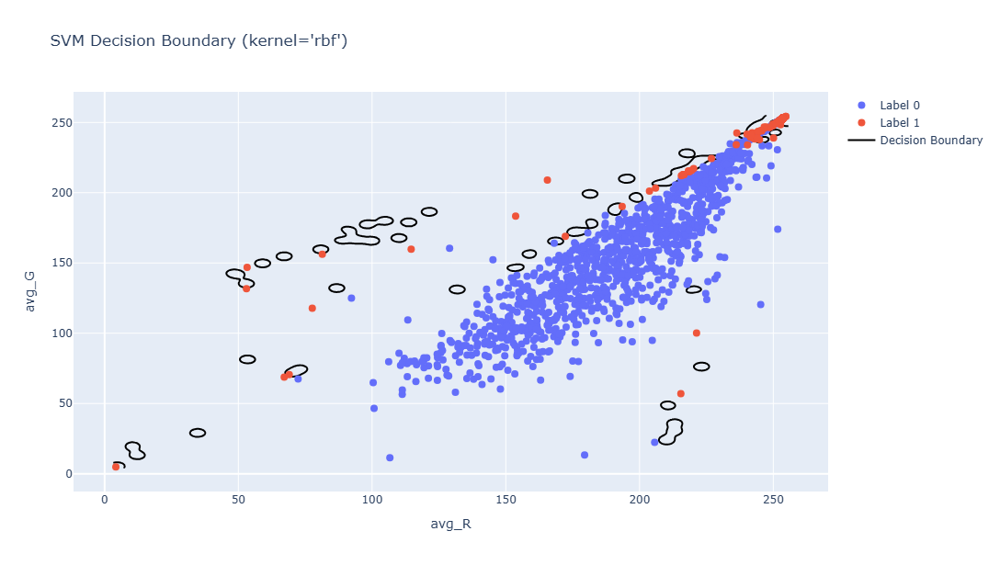

In [72]:
# Ensure patch_name is aligned with test set
patch_names_test = df_test['patch_name'].values

svm2 = svm(X_train, y_train, X_test, y_test, kernel='rbf', plot_decision=True, patch_names=patch_names_test)


Accuracy: 0.9517133956386293

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      1058
           1       0.83      0.91      0.87       226

    accuracy                           0.95      1284
   macro avg       0.91      0.94      0.92      1284
weighted avg       0.95      0.95      0.95      1284


Confusion Matrix:
 [[1016   42]
 [  20  206]]


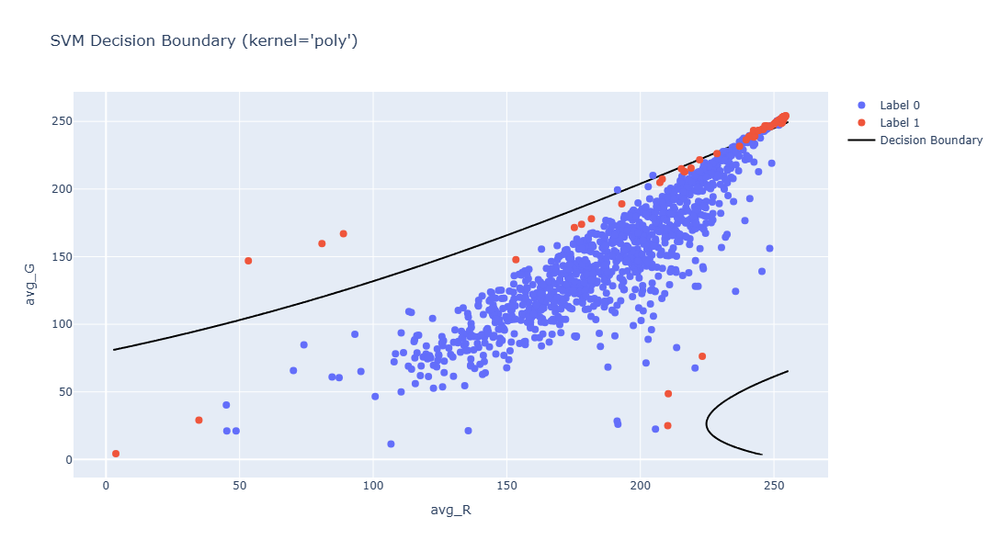

In [65]:
# Ensure patch_name is aligned with test set
patch_names_test = df_test['patch_name'].values

svm2 = svm(X_train, y_train, X_test, y_test, kernel='poly', plot_decision=True, patch_names=patch_names_test)


## avg_R, std_R

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Feature and label selection
X = df[['avg_R', 'std_R']].values
y = df['label'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Accuracy: 0.9696699375557538

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1034
           1       0.85      0.74      0.79        87

    accuracy                           0.97      1121
   macro avg       0.92      0.86      0.89      1121
weighted avg       0.97      0.97      0.97      1121


Confusion Matrix:
 [[1023   11]
 [  23   64]]


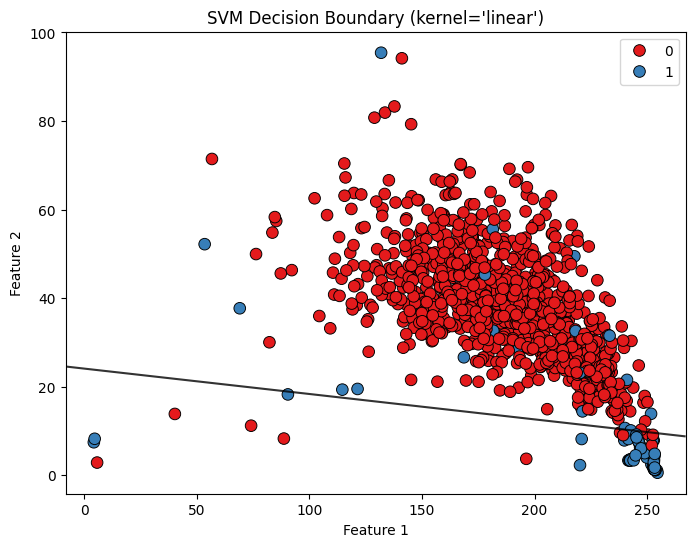

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
svm(X_train, y_train, X_test, y_test, kernel='linear', plot_decision=True)

Accuracy: 0.9705619982158786

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1034
           1       0.90      0.70      0.79        87

    accuracy                           0.97      1121
   macro avg       0.94      0.85      0.89      1121
weighted avg       0.97      0.97      0.97      1121


Confusion Matrix:
 [[1027    7]
 [  26   61]]


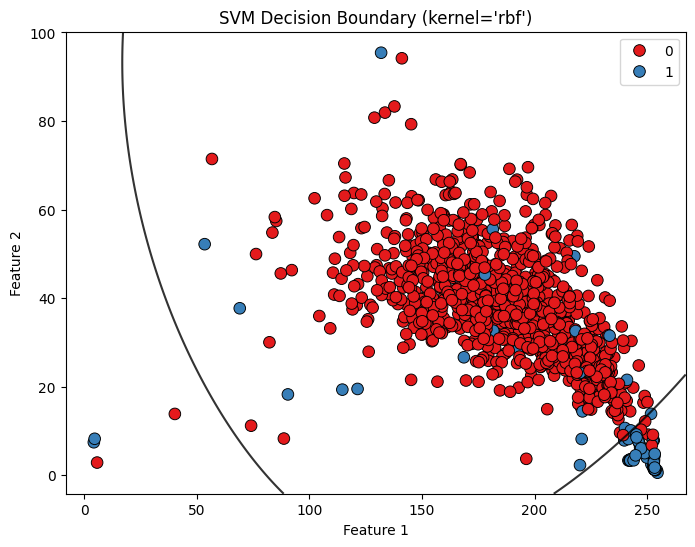

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [30]:
svm(X_train, y_train, X_test, y_test, kernel='rbf', plot_decision=True)

## avg_R, std_G

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Feature and label selection
X = df[['avg_R', 'std_G']].values
y = df['label'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Accuracy: 0.9750223015165032

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1034
           1       0.90      0.76      0.82        87

    accuracy                           0.98      1121
   macro avg       0.94      0.88      0.91      1121
weighted avg       0.97      0.98      0.97      1121


Confusion Matrix:
 [[1027    7]
 [  21   66]]


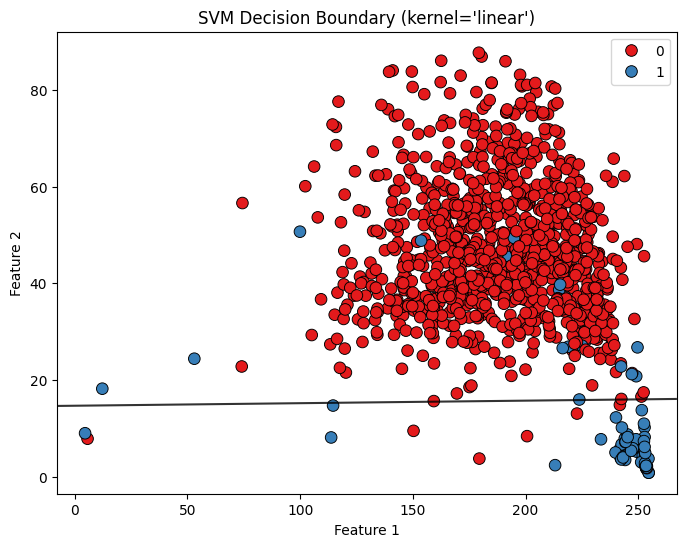

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
svm(X_train, y_train, X_test, y_test, kernel='linear', plot_decision=True)

Accuracy: 0.9750223015165032

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1034
           1       0.92      0.75      0.82        87

    accuracy                           0.98      1121
   macro avg       0.95      0.87      0.90      1121
weighted avg       0.97      0.98      0.97      1121


Confusion Matrix:
 [[1028    6]
 [  22   65]]


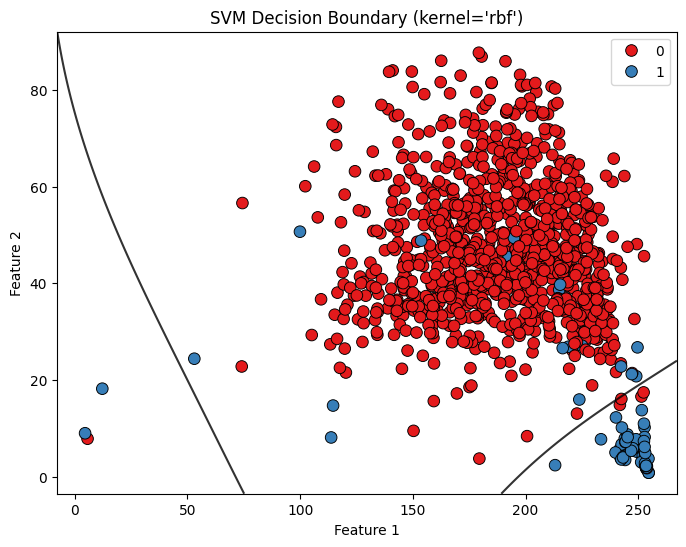

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
svm(X_train, y_train, X_test, y_test, kernel='rbf', plot_decision=True)

## testing on the new file

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Shuffle the dataframe
df = pd.read_csv("TCGA-AA-3846_nonMSIH.csv")

# Feature and label selection
X = df[['avg_R', 'avg_G','avg_B']].values

X_test_scaled = scaler.transform(X)

y_pred = svm_model.predict(X_test_scaled)

import os
import shutil
import pandas as pd

# Ensure your DataFrame `df` and your y_pred are available
# For this example, assume df and y_pred are aligned

# Folder where images should be copied
output_folder = 'test_label_linear2'
os.makedirs(output_folder, exist_ok=True)

# Loop through the predictions
for i, pred in enumerate(y_pred):
    if pred == 1:
        patch_name = df.loc[i, 'patch_name']
        
        # Extract folder prefix from PatchName
        prefix = '_'.join(patch_name.split('_')[:2])  # e.g., TCGA-AA-3679_nonMSIH
        
        # Construct full path
        src_path = os.path.join(f"./{prefix}", patch_name)
        dst_path = os.path.join(output_folder, patch_name)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
        else:
            print(f"File not found: {src_path}")

In [38]:
len(y_pred[y_pred==1])

402

In [40]:
import os
import shutil
import pandas as pd

# Ensure your DataFrame `df` and your y_pred are available
# For this example, assume df and y_pred are aligned

# Folder where images should be copied
output_folder = 'test_label_linear2'
os.makedirs(output_folder, exist_ok=True)

# Loop through the predictions
for i, pred in enumerate(y_pred):
    if pred == 1:
        patch_name = df.loc[i, 'patch_name']
        
        # Extract folder prefix from PatchName
        prefix = '_'.join(patch_name.split('_')[:2])  # e.g., TCGA-AA-3679_nonMSIH
        
        # Construct full path
        src_path = os.path.join(f"./{prefix}", patch_name)
        dst_path = os.path.join(output_folder, patch_name)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
        else:
            print(f"File not found: {src_path}")

In [41]:
y_pred = svm2.predict(X)

In [42]:
import os
import shutil
import pandas as pd

# Ensure your DataFrame `df` and your y_pred are available
# For this example, assume df and y_pred are aligned

# Folder where images should be copied
output_folder = 'test_label_nonlinear'
os.makedirs(output_folder, exist_ok=True)

# Loop through the predictions
for i, pred in enumerate(y_pred):
    if pred == 1:
        patch_name = df.loc[i, 'patch_name']
        
        # Extract folder prefix from PatchName
        prefix = '_'.join(patch_name.split('_')[:2])  # e.g., TCGA-AA-3679_nonMSIH
        
        # Construct full path
        src_path = os.path.join(f"./{prefix}", patch_name)
        dst_path = os.path.join(output_folder, patch_name)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
        else:
            print(f"File not found: {src_path}")

## Merging csv

In [89]:
import os
import pandas as pd

def merge_csv_files(folder_path, output_file):
    """
    Merge all CSV files in a folder into one CSV file.
    
    Parameters:
    - folder_path: Path to the folder containing CSV files
    - output_file: Full path to the output merged CSV file
    """
    # List all .csv files in the folder
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    
    # Read and concatenate all CSVs
    df_list = []
    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df_list.append(df)
    
    merged_df = pd.concat(df_list, ignore_index=True)
    
    # Save to output file
    merged_df.to_csv(output_file, index=False)
    print(f"Merged {len(csv_files)} CSV files into '{output_file}'")

# Example usage:
folder = r"D:\Aamir Gulzar\KSA_project2\dataset\patches_metadata"  # Replace with your folder
output = r"D:\Aamir Gulzar\KSA_project2\dataset\merged_output.csv"
merge_csv_files(folder, output)

Merged 417 CSV files into 'D:\Aamir Gulzar\KSA_project2\dataset\merged_output.csv'


## Running model on csv

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Shuffle the dataframe
df = pd.read_csv(r"D:\Aamir Gulzar\KSA_project2\dataset\merged_output.csv")

# Feature and label selection
X = df[['avg_R', 'avg_G']].values

In [ ]:
y_pred = svm1.predict(X)

In [ ]:
df['label']=y_pred

In [ ]:
import os
import shutil
import pandas as pd

# Ensure your DataFrame `df` and your y_pred are available
# For this example, assume df and y_pred are aligned

# Folder where images should be copied
output_folder = 'test_label_overall'
os.makedirs(output_folder, exist_ok=True)

# Loop through the predictions
for i, pred in enumerate(y_pred):
    if pred == 1:
        patch_name = df.loc[i, 'patch_name']
        
        # Extract folder prefix from PatchName
        prefix = '_'.join(patch_name.split('_')[:2])  # e.g., TCGA-AA-3679_nonMSIH
        
        # Construct full path
        src_path = os.path.join(f"./{prefix}", patch_name)
        dst_path = os.path.join(output_folder, patch_name)
        
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
        else:
            print(f"File not found: {src_path}")